Hücre 1: Kütüphanelerin Yüklenmesi ve Verinin Okunması
Bu bölümde gerekli araçları içeri aktarıyor ve MNIST dosyalarını ikili (binary) formattan numpy dizilerine çeviriyoruz.

In [35]:
import numpy as np
import struct

def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows * cols)  # 60000 x 784
    return images

def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Dosya yollarını kontrol etmeyi unutma
X_train = load_mnist_images('train-images.idx3-ubyte')
y_train = load_mnist_labels('train-labels.idx1-ubyte')
X_test  = load_mnist_images('t10k-images.idx3-ubyte')
y_test  = load_mnist_labels('t10k-labels.idx1-ubyte')

print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test:  {X_test.shape},  Labels: {y_test.shape}")
print(f"Örnek label'lar: {y_train[:10]}")
print(f"Piksel değer aralığı: {X_train.min()} - {X_train.max()}")

Train: (60000, 784), Labels: (60000,)
Test:  (10000, 784),  Labels: (10000,)
Örnek label'lar: [5 0 4 1 9 2 1 3 1 4]
Piksel değer aralığı: 0 - 255


Hücre 2: Normalizasyon ve One-Hot Encoding
Veriyi 0-255 arasından 0-1 arasına çekip etiketleri vektör formatına dönüştürüyoruz.
Neden: Büyük sayılar gradyanı patlatır, eğitim dengesizleşir.
One-hot encoding — label'ları 0-9'dan vektöre(altta örnek var) çevir.
Neden: Model 10 sınıf için 10 olasılık üretecek.
5 → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]

In [36]:
# 1. Normalizasyon
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# 2. One-hot encoding
def one_hot(labels, num_classes=10):
    y_etiket_matris = np.zeros((len(labels), num_classes)) 
    y_etiket_matris[np.arange(len(labels)), labels] = 1 
    return y_etiket_matris

y_train_sifirli = one_hot(y_train)
y_test_sifirli  = one_hot(y_test)

print(f"İlk label: {y_train[0]} → {y_train_sifirli[0]}")
print(f"Normalizasyon sonrası: {X_train.min()} - {X_train.max()}")

İlk label: 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Normalizasyon sonrası: 0.0 - 1.0


Hücre 3: Model Parametrelerinin Başlatılması
Ağırlıkları (Weights) ve sapmaları (Bias) rastgele değerlerle oluşturuyoruz.
Artık X_train, X_test, y_train_sifirli, y_test_sifirli ile modelimizi eğitebiliriz.
MLP (2 katmanlı) parametreleri aşağıdaki gibi olabilir:
input_size = 784  # 28x28 piksel    
hidden_size1 = 128  # Birinci gizli katman boyutu   
hidden_size2 = 64 # İkinci gizli katman boyutu
çıktı_size = 10   # 10 sınıf (0-9)
aktivasyon fonksiyonu = 'relu' 
çıktı aktivasyonu = 'softmax' 

In [37]:
np.random.seed(42)  # Sabit sonuçlar için
#şimdi rasgele ağırlıklar ve bias'lar oluşturabiliriz:
# Ağırlıkları neden 0.01 ile çarpıyoruz? Çünkü rasgele ağırlıklar genellikle küçük değerler olmalıdır. 
# Büyük değerler gradyan patlamasına neden olabilir, bu da eğitim sürecini zorlaştırır. 
# Küçük değerler ise daha stabil bir eğitim sağlar.
def init_weights():
    W1 = np.random.randn(784, 128) * 0.01
    b1 = np.zeros((1, 128))
    
    W2 = np.random.randn(128, 64) * 0.01
    b2 = np.zeros((1, 64))
    
    W3 = np.random.randn(64, 10) * 0.01
    b3 = np.zeros((1, 10))
    
    return W1, b1, W2, b2, W3, b3

W1, b1, W2, b2, W3, b3 = init_weights()

print(f"W1: {W1.shape}")  # 784 x 128
print(f"W2: {W2.shape}")  # 128 x 64
print(f"W3: {W3.shape}")  # 64  x 10

W1: (784, 128)
W2: (128, 64)
W3: (64, 10)


Hücre 4: Aktivasyon Fonksiyonları ve İleri Yayılım (Forward Pass)

In [38]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# neden relu? Çünkü ReLU, negatif değerleri sıfırlar ve pozitif değerleri olduğu gibi bırakır. 
# Bu, modelin daha hızlı öğrenmesini sağlar ve gradyan kaybını azaltır. 
# neden tanh ve sigmoid değil? çünkü büyük değerlerde eğim sıfıra yaklaşır, bu da gradyan kaybına neden olabilir. öğrenme olmaz.

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
#şimdi forward pass'i tanımlayalım:
def forward_pass(X):
    # 1. Katman
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    
    # 2. Katman
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    
    # Çıktı Katmanı
    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3

# Model daha eğitilmediği için tahminler rastgele olacaktır. 
# Ancak çıktıların olasılık dağılımı şeklinde olduğunu görebiliriz.
# Tek bir görüntüyle test
Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_train[:1])
print(f"Tahmin: {np.argmax(A3)}, Gerçek: {y_train[0]}")

Tahmin: 3, Gerçek: 5


Hücre 5: Kayıp Fonksiyonu ve Geri Yayılım (Backward Pass)

In [39]:
#şimdi loss fonksiyonunu tanımlayalım:
def cross_entropy_loss(y_pred, y_true):
    n = y_true.shape[0]
    # Log(0) patlamasını önlemek için küçük epsilon ekliyoruz
    epsilon = 1e-8
    loss = -np.sum(y_true * np.log(y_pred + epsilon)) / n
    return loss

def backward_pass(X, y_true, Z1, A1, Z2, A2, Z3, A3):
    n = X.shape[0]
    
    # Çıktı katmanı gradyanı
    # Softmax + Cross-entropy türevi birleşince bu kadar sade çıkıyor
    dZ3 = A3 - y_true
    dW3 = A2.T @ dZ3 / n
    db3 = np.sum(dZ3, axis=0, keepdims=True) / n
    
    # 2. gizli katman
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2 / n
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n
    
    # 1. gizli katman
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 / n
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n
    
    return dW1, db1, dW2, db2, dW3, db3

def update_weights(dW1, db1, dW2, db2, dW3, db3, learning_rate=0.01):
    global W1, b1, W2, b2, W3, b3
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

Hücre 6: Eğitim Döngüsünün Tanımlanması ve Başlatılması

In [40]:
def train(X, y, epochs=40, batch_size=64, learning_rate=0.01):
    n = X.shape[0]
    
    for epoch in range(epochs):
        # Veriyi karıştır
        idx = np.random.permutation(n)
        X_shuffled = X[idx]
        y_shuffled = y[idx]
        
        epoch_loss = 0
        num_batches = 0
        
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch)
            loss = cross_entropy_loss(A3, y_batch)
            epoch_loss += loss
            num_batches += 1
            
            dW1, db1, dW2, db2, dW3, db3 = backward_pass(
                X_batch, y_batch, Z1, A1, Z2, A2, Z3, A3
            )
            update_weights(dW1, db1, dW2, db2, dW3, db3, learning_rate)
        
        avg_loss = epoch_loss / num_batches
        _, _, _, _, _, A3_test = forward_pass(X_test)
        predictions = np.argmax(A3_test, axis=1)
        accuracy = np.mean(predictions == y_test)
        
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.4f}")

# Eğitimi başlat
train(X_train, y_train_sifirli, epochs=100, batch_size=64, learning_rate=0.01)

Epoch  1 | Loss: 2.3016 | Test Accuracy: 0.1135
Epoch  2 | Loss: 2.3000 | Test Accuracy: 0.1135
Epoch  3 | Loss: 2.2928 | Test Accuracy: 0.2068
Epoch  4 | Loss: 2.0532 | Test Accuracy: 0.4510
Epoch  5 | Loss: 1.1465 | Test Accuracy: 0.7477
Epoch  6 | Loss: 0.6889 | Test Accuracy: 0.8185
Epoch  7 | Loss: 0.5670 | Test Accuracy: 0.8513
Epoch  8 | Loss: 0.4822 | Test Accuracy: 0.8678
Epoch  9 | Loss: 0.4379 | Test Accuracy: 0.8786
Epoch 10 | Loss: 0.4087 | Test Accuracy: 0.8867
Epoch 11 | Loss: 0.3851 | Test Accuracy: 0.8893
Epoch 12 | Loss: 0.3636 | Test Accuracy: 0.8983
Epoch 13 | Loss: 0.3419 | Test Accuracy: 0.9033
Epoch 14 | Loss: 0.3216 | Test Accuracy: 0.9066
Epoch 15 | Loss: 0.3010 | Test Accuracy: 0.9161
Epoch 16 | Loss: 0.2822 | Test Accuracy: 0.9216
Epoch 17 | Loss: 0.2646 | Test Accuracy: 0.9254
Epoch 18 | Loss: 0.2488 | Test Accuracy: 0.9299
Epoch 19 | Loss: 0.2339 | Test Accuracy: 0.9331
Epoch 20 | Loss: 0.2211 | Test Accuracy: 0.9369
Epoch 21 | Loss: 0.2095 | Test Accuracy:

Hücre 7: Hata Analizi

In [41]:
import matplotlib.pyplot as plt

# Confusion matrix
from collections import defaultdict

_, _, _, _, _, A3_test = forward_pass(X_test)
predictions = np.argmax(A3_test, axis=1)

# Hangi rakamlar karışıyor?
errors = defaultdict(list)
for i, (pred, true) in enumerate(zip(predictions, y_test)):
    if pred != true:
        errors[true].append(pred)

print("Rakam | Yanlış tahmin sayısı | En çok karışılan")
print("-" * 50)
for digit in range(10):
    if digit in errors:
        most_confused = max(set(errors[digit]), key=errors[digit].count)
        print(f"  {digit}   |        {len(errors[digit]):3d}          |       {most_confused}")

Rakam | Yanlış tahmin sayısı | En çok karışılan
--------------------------------------------------
  0   |         13          |       6
  1   |         13          |       8
  2   |         30          |       8
  3   |         26          |       5
  4   |         21          |       9
  5   |         31          |       3
  6   |         27          |       4
  7   |         33          |       1
  8   |         30          |       5
  9   |         36          |       4


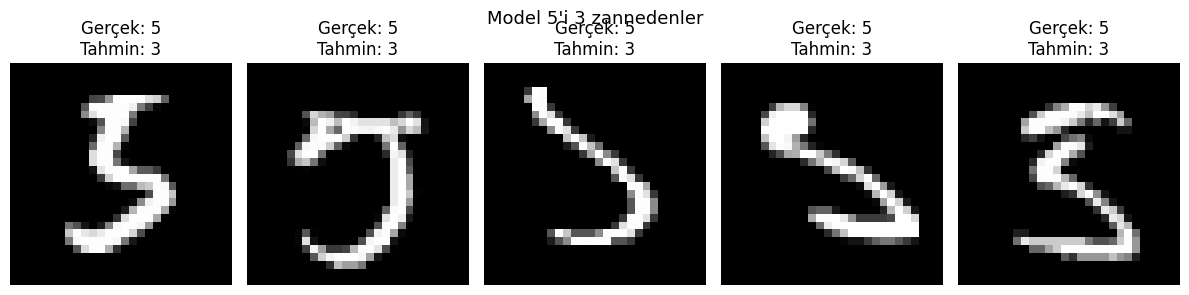

In [42]:
# Yanlış tahmin edilen 5'leri bul
wrong_5s = [i for i, (pred, true) in enumerate(zip(predictions, y_test)) 
            if true == 5 and pred == 3]

# İlk 5 tanesini göster
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, wrong_5s[:5]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Gerçek: 5\nTahmin: 3")
    ax.axis('off')
plt.suptitle("Model 5'i 3 zannedenler", fontsize=13)
plt.tight_layout()
plt.show()